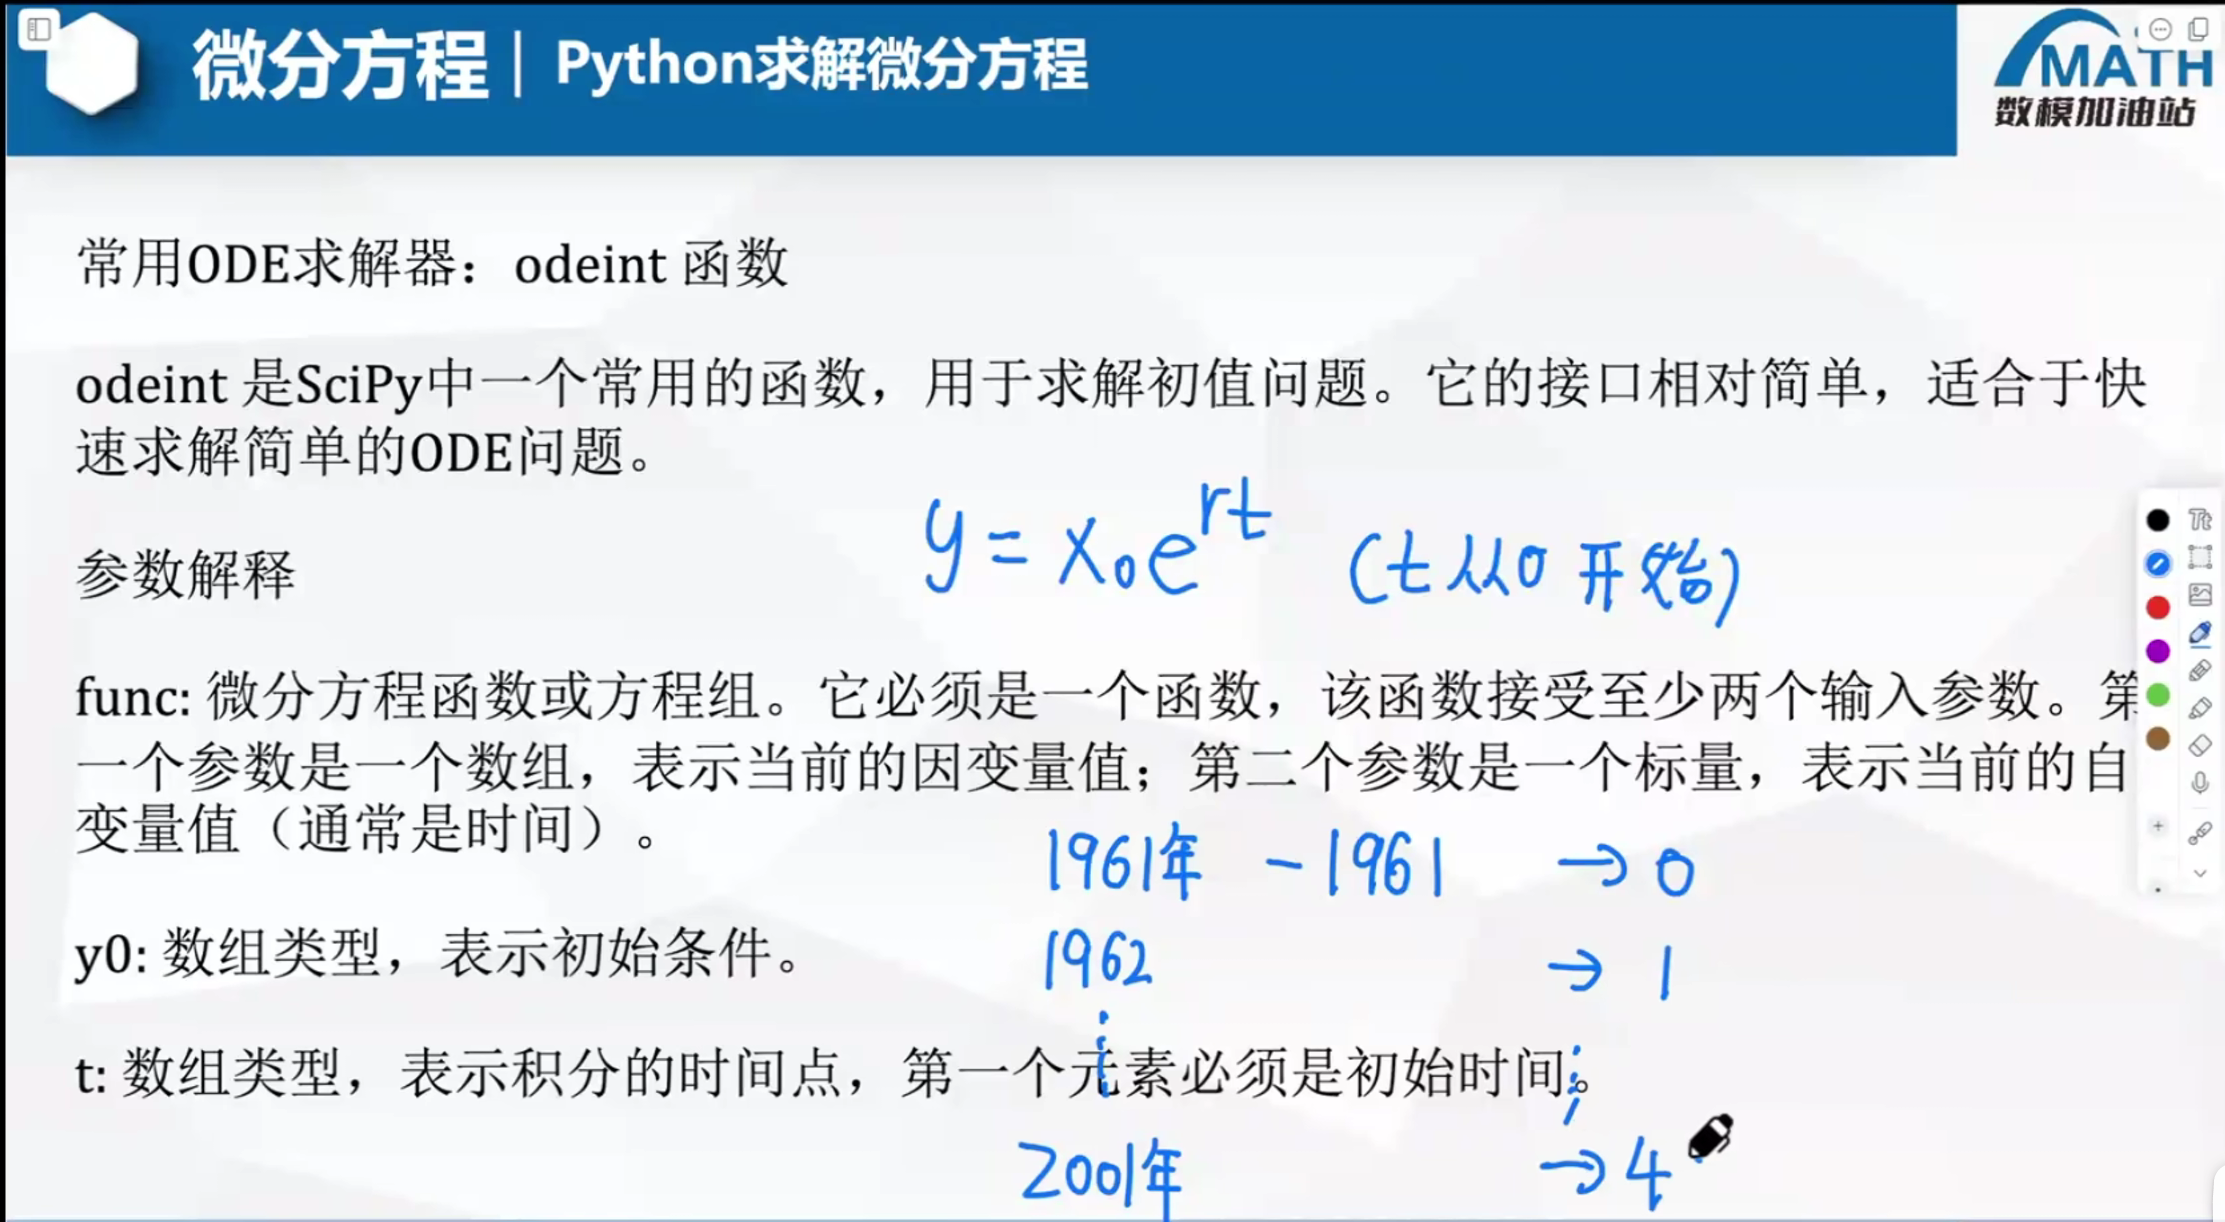

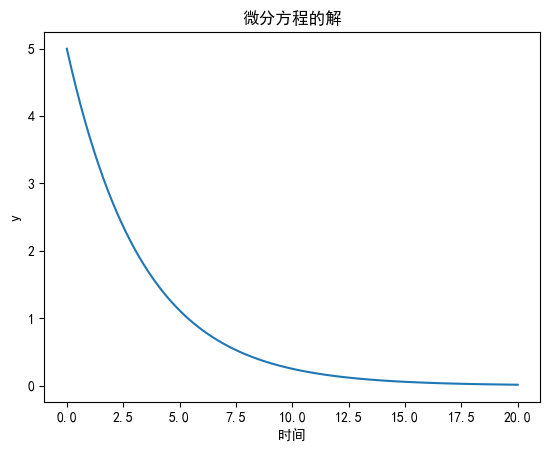

In [3]:
from scipy.integrate import odeint
import numpy as np

# 微分方程函数
def model(y, t):
    k = 0.3
    dydt = -k * y
    return dydt

# 初始条件
y0 = 5

# 时间点
t = np.linspace(0, 20, 100)

# 求解微分方程
sol = odeint(model, y0, t)

# 绘图
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体  
plt.rcParams['axes.unicode_minus'] = False    # 正确显示负号

plt.plot(t, sol.ravel())
plt.xlabel('时间')
plt.ylabel('y')
plt.title('微分方程的解')
plt.show()

[[5.         4.70596841 4.42921936 4.16874695 3.9235999  3.6928758
  3.47572117 3.27133069 3.07881715 2.89746137 2.72670125 2.56598889
  2.41479059 2.27258683 2.1388723  2.01315587 1.89496064 1.78382386
  1.67929702 1.58094578 1.48835001 1.40110377 1.31881539 1.24121567
  1.1681224  1.09930476 1.03453826 0.97360468 0.9162921  0.86239492
  0.8117138  0.76405573 0.71923398 0.6770681  0.63738398 0.60001377
  0.56479592 0.53158401 0.50028988 0.47082009 0.44308007 0.41697786
  0.39242407 0.36933196 0.34761737 0.32719875 0.30799716 0.28993627
  0.27294233 0.25694423 0.24187344 0.22766409 0.2142678  0.20164951
  0.1897694  0.17858872 0.1680698  0.15817608 0.14887204 0.14012326
  0.13189642 0.12415926 0.11688061 0.11003038 0.10357955 0.09750021
  0.091767   0.08636476 0.08127741 0.07648864 0.07198259 0.06774383
  0.06375741 0.06000879 0.0564839  0.05316913 0.05005129 0.04711767
  0.04435598 0.04175441 0.03930157 0.03698901 0.03481072 0.03275984
  0.03082968 0.02901376 0.02730576 0.02569957 0.0

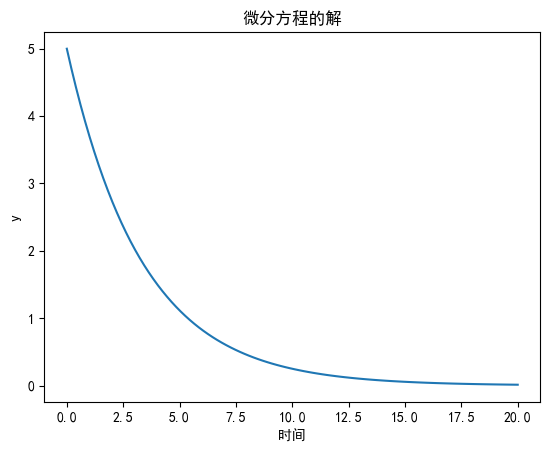

In [5]:
from scipy.integrate import solve_ivp
import numpy as np

# 微分方程函数
def model(t, y):
    k = 0.3
    dydt = -k * y
    return dydt

# 初始条件
y0 = [5]

# 时间区间
t_span = (0, 20)

# 求解ODE
sol = solve_ivp(model, t_span, y0, t_eval=np.linspace(0, 20, 100))

# 输出结果
print(sol.y)

# 绘图
import matplotlib.pyplot as plt
# 添加中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号'-'显示为方块的问题

plt.plot(sol.t, sol.y[0])
plt.xlabel('时间')
plt.ylabel('y')
plt.title('微分方程的解')
plt.show()

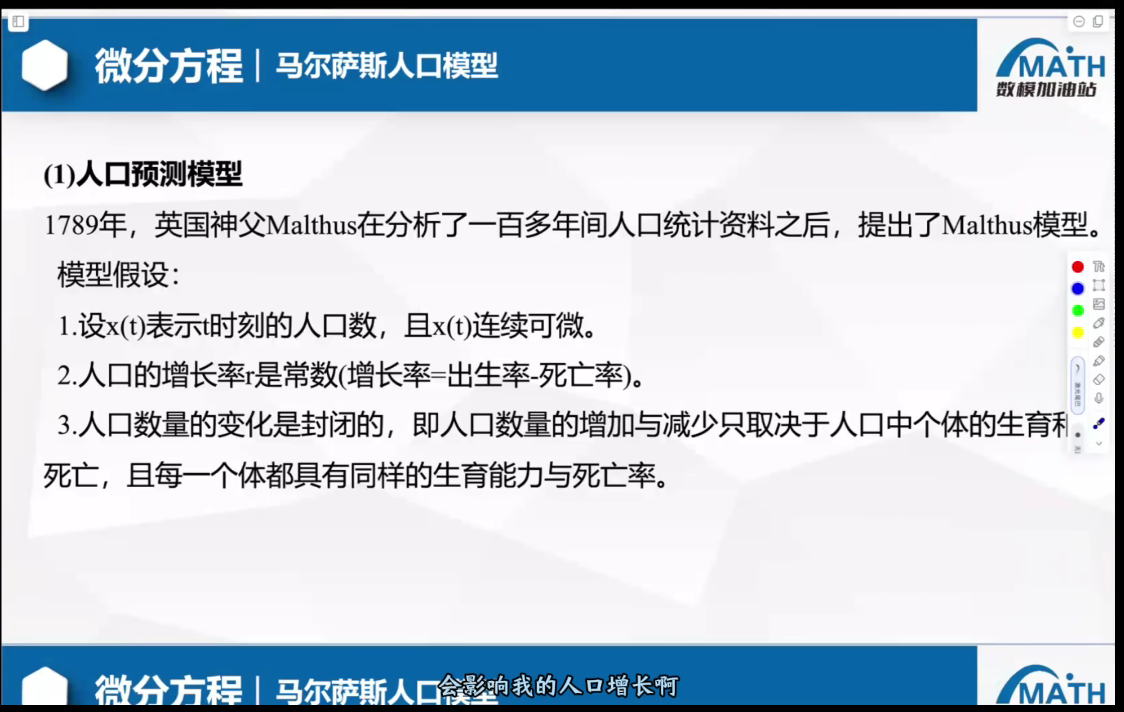

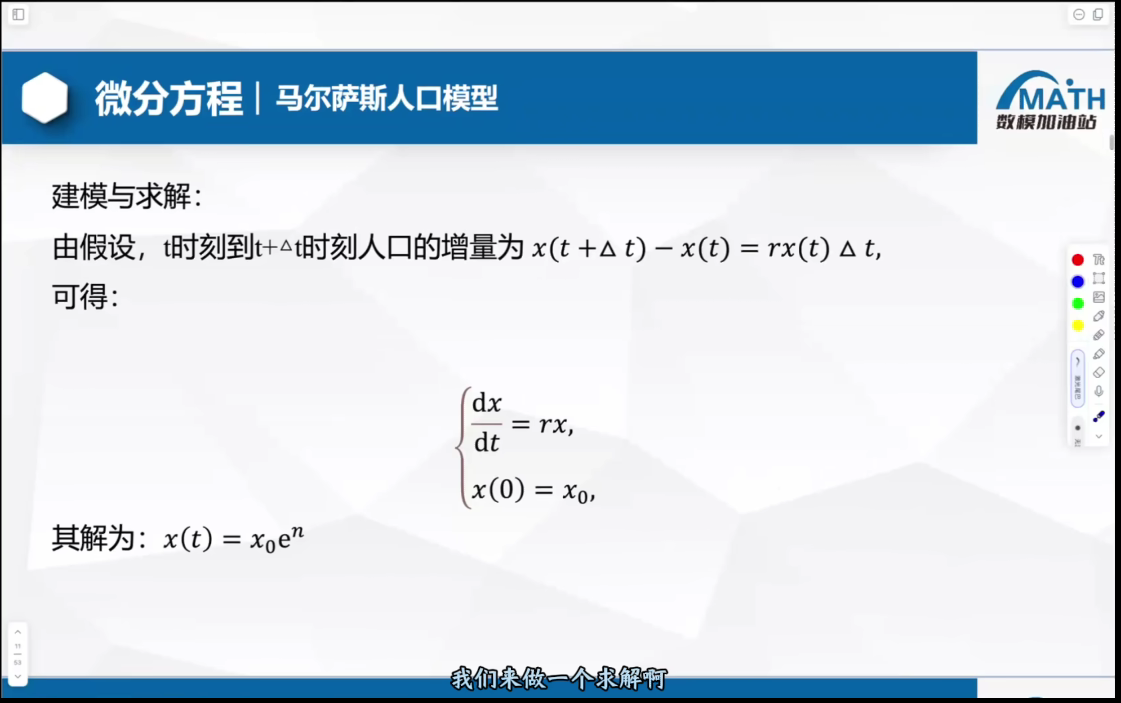

Text(0.5, 1.0, '马尔萨斯人口模型')

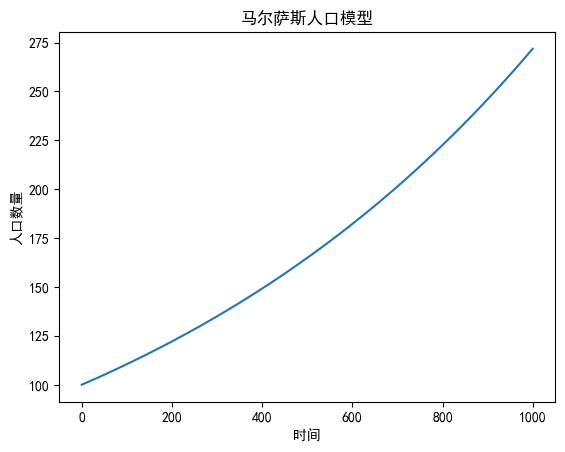

In [6]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False    # 正确显示负号

# 马尔萨斯人口模型微分方程
def malthus_model(P, t):
    r = 0.001  # 人口增长率
    dPdt = r * P
    return dPdt

# 初始人口数量
P0 = 100

# 时间范围
t = np.linspace(0, 1000, 200)

# 求解微分方程
P = odeint(malthus_model, P0, t)

# 绘图
plt.plot(t, P.ravel())
plt.xlabel('时间')
plt.ylabel('人口数量')
plt.title('马尔萨斯人口模型')

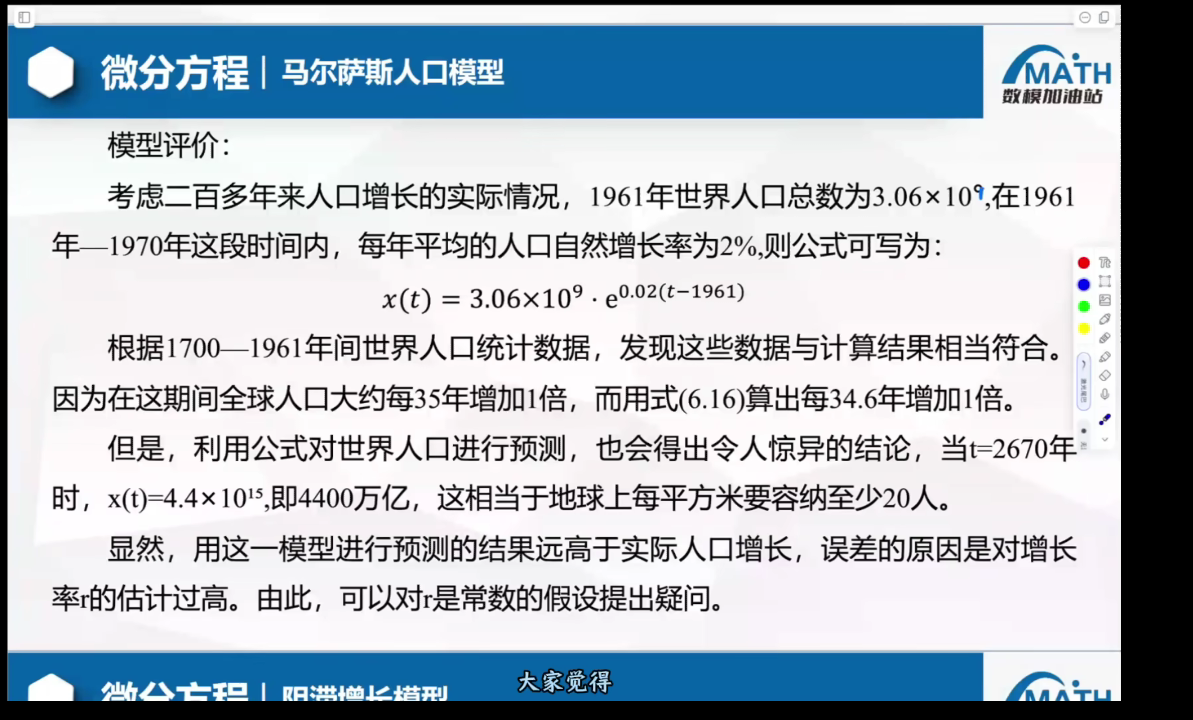

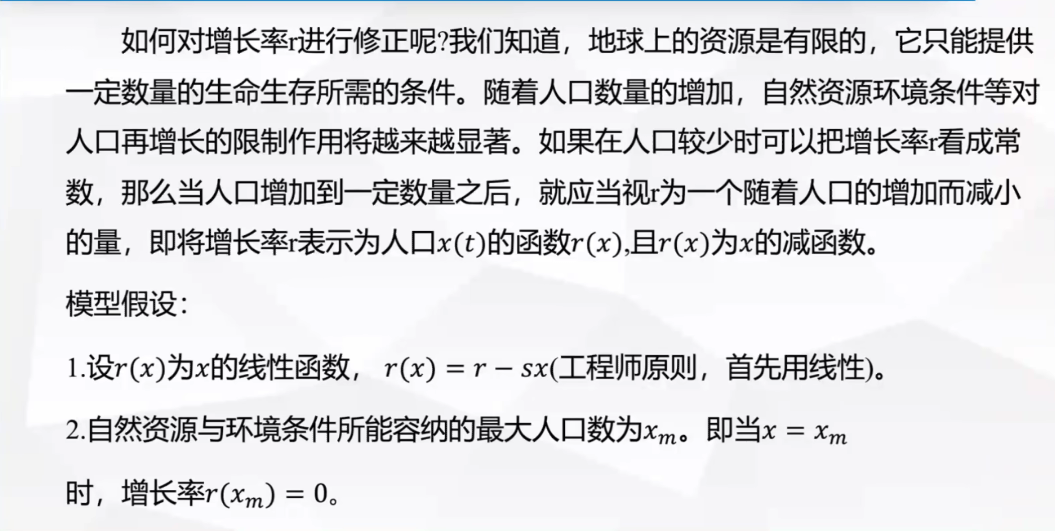

 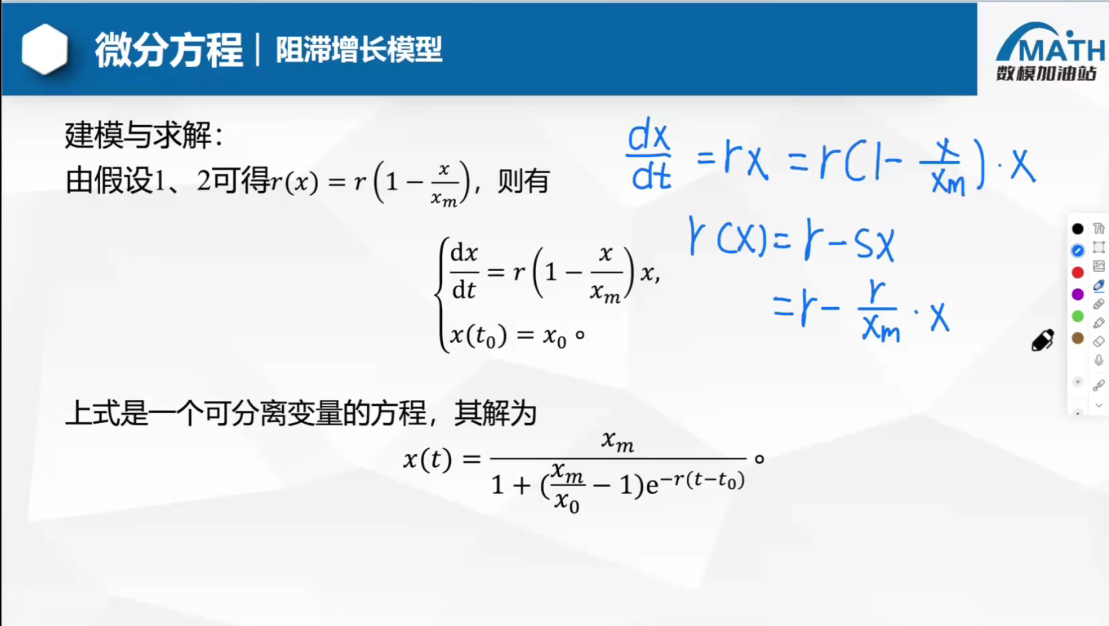

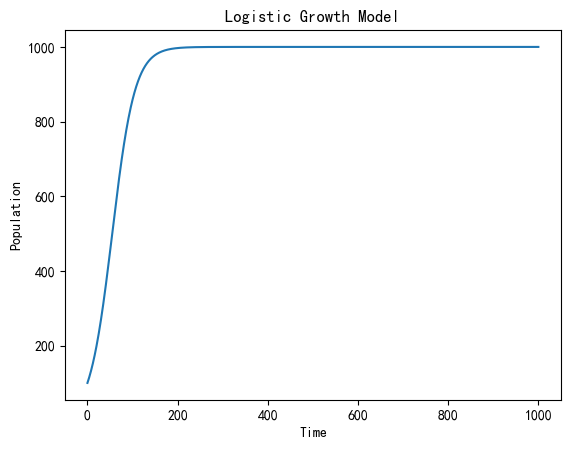

In [7]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

# 阻滞增长模型微分方程
def logistic_growth_model(P, t, r, K):
    dPdt = r * P * (1 - P / K)
    return dPdt

# 初始条件和参数
P0 = 100  # 初始人口数量
t = np.linspace(0, 1000, 1000)  # 时间范围
r = 0.04  # 人口增长率
K = 1000  # 环境容量

# 求解微分方程
P = odeint(logistic_growth_model, P0, t, args=(r, K))

# 绘制人口随时间变化的图像
plt.plot(t, P)
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Logistic Growth Model')
plt.show()

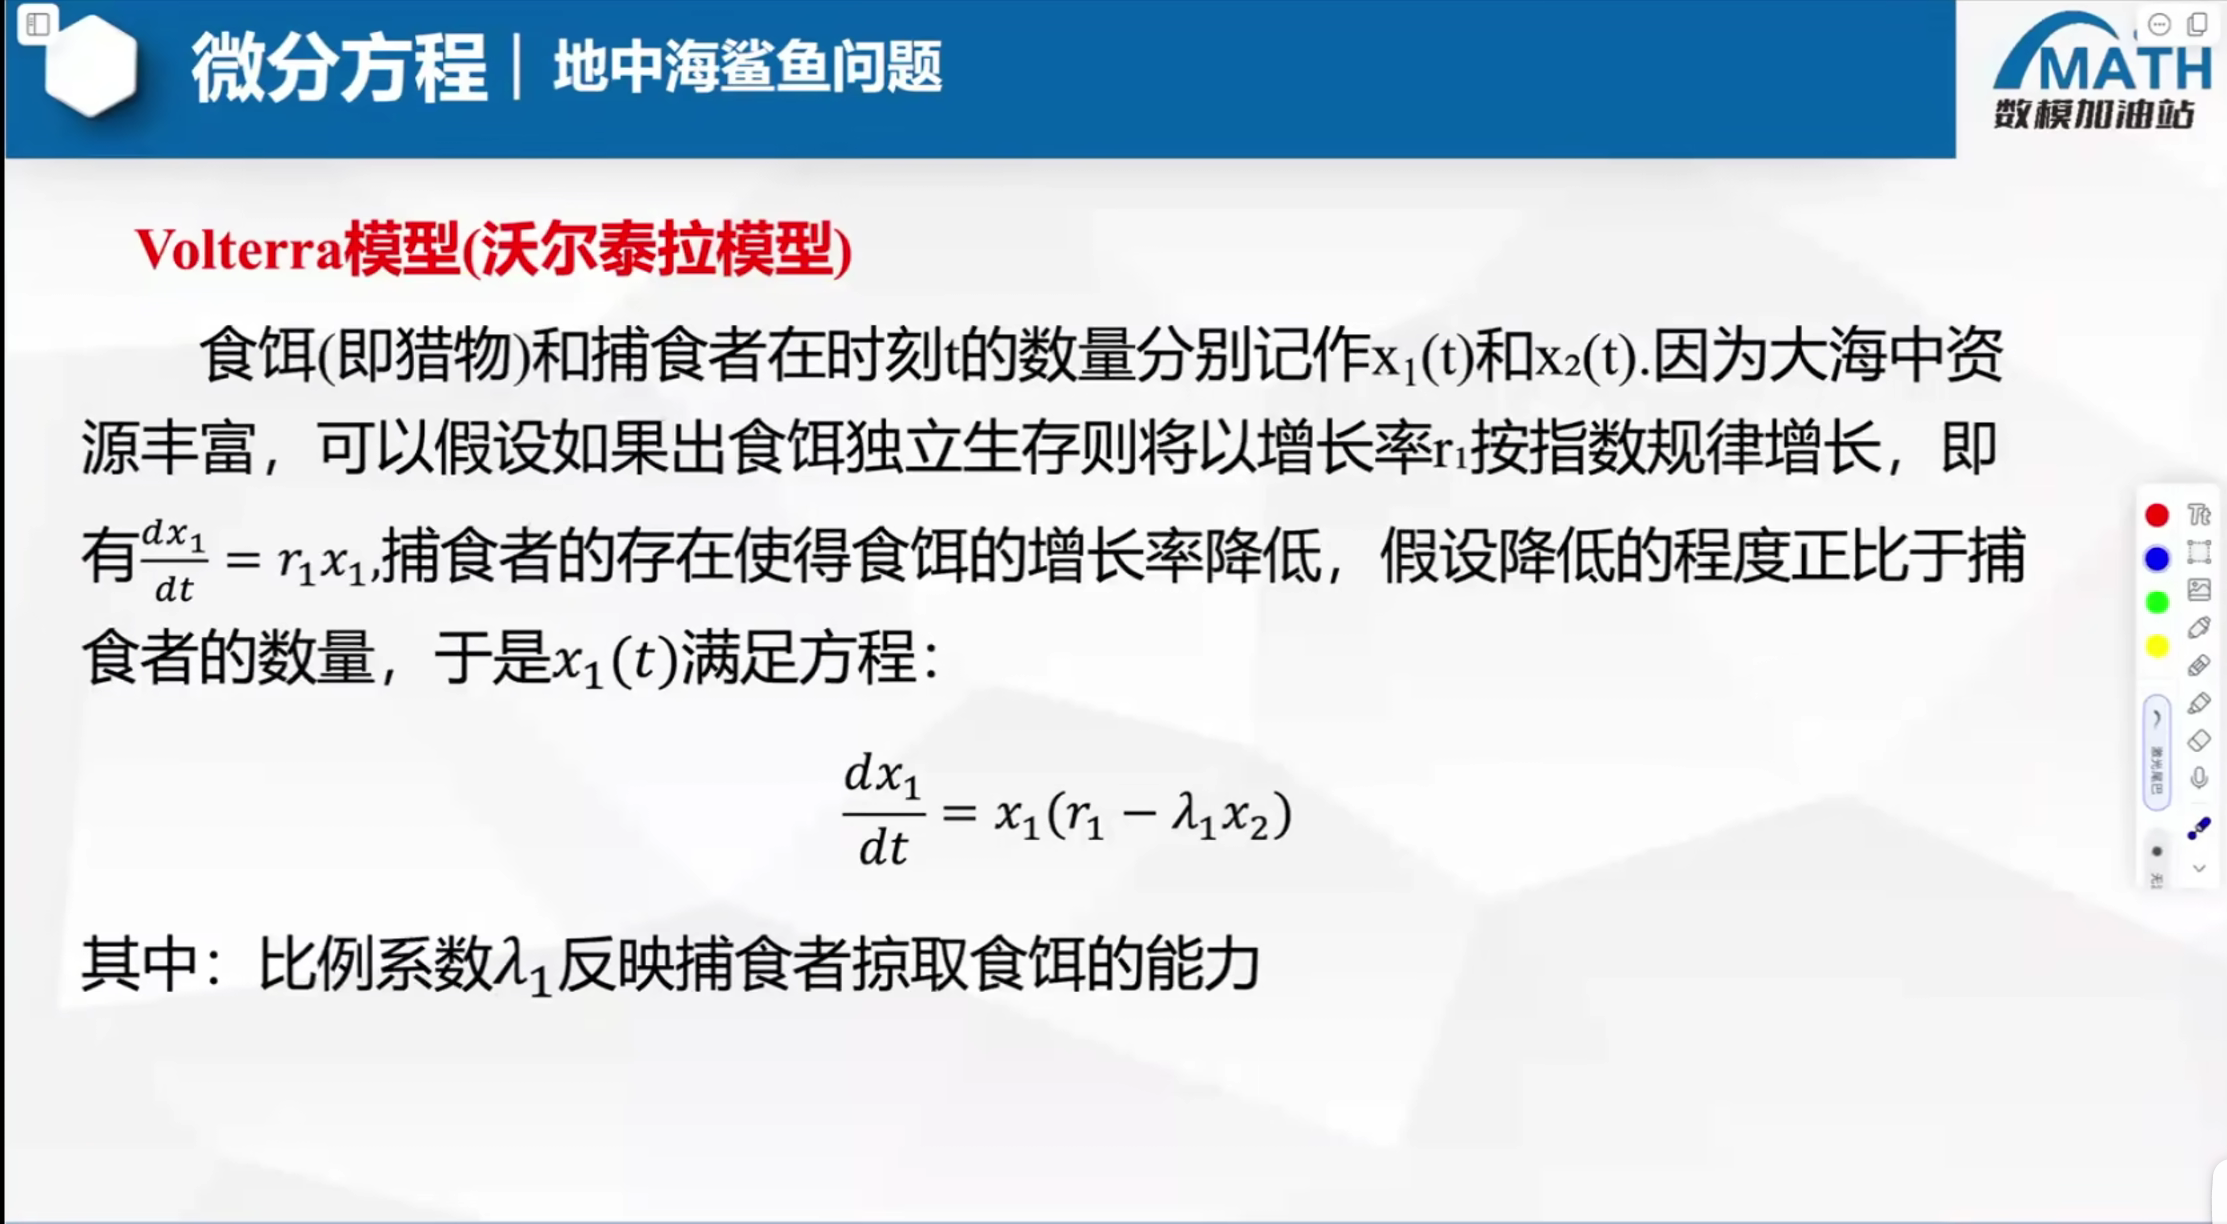

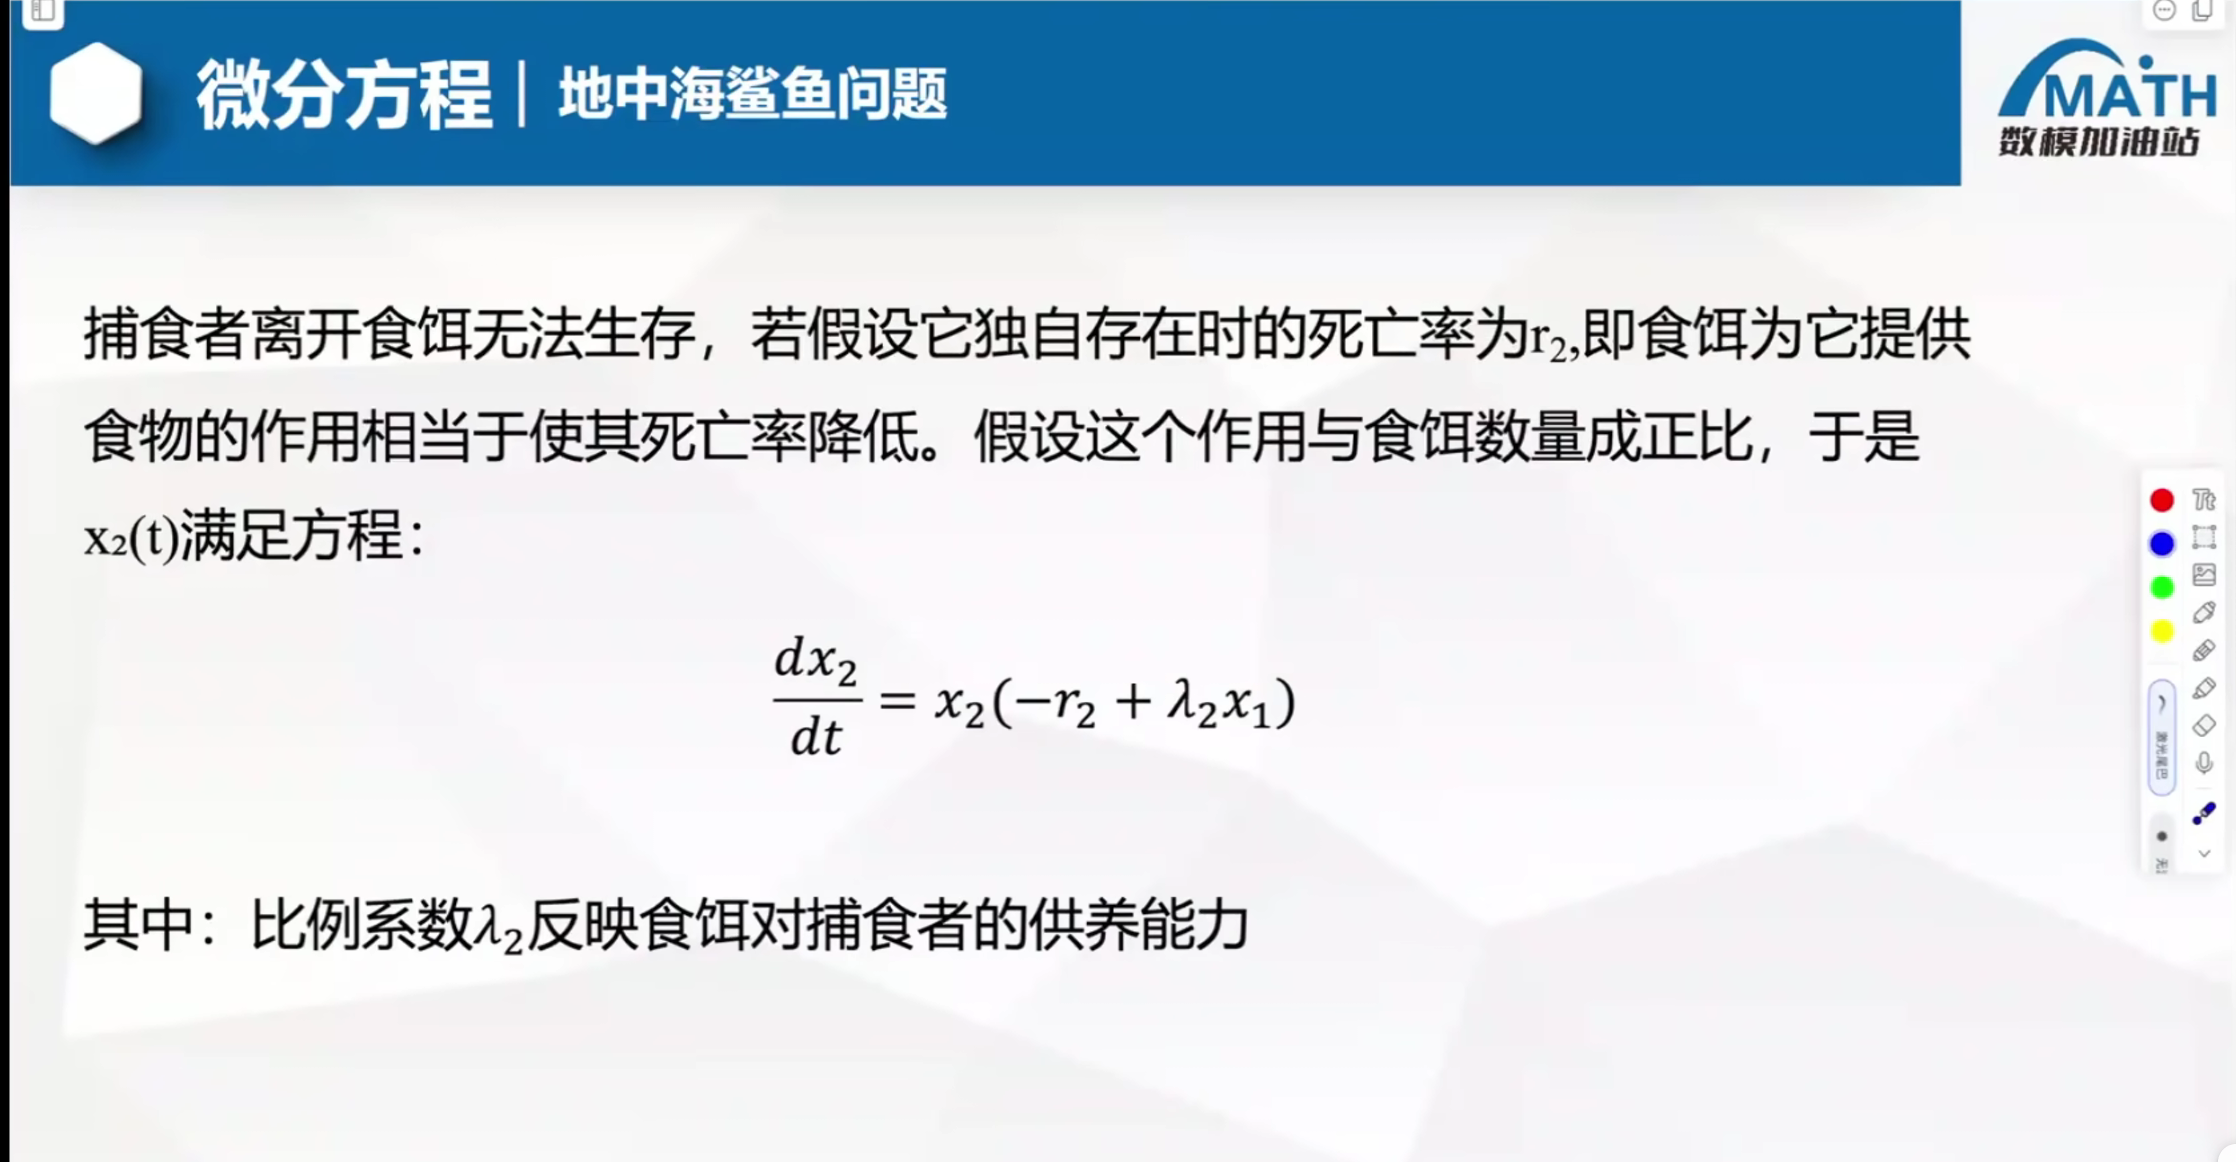

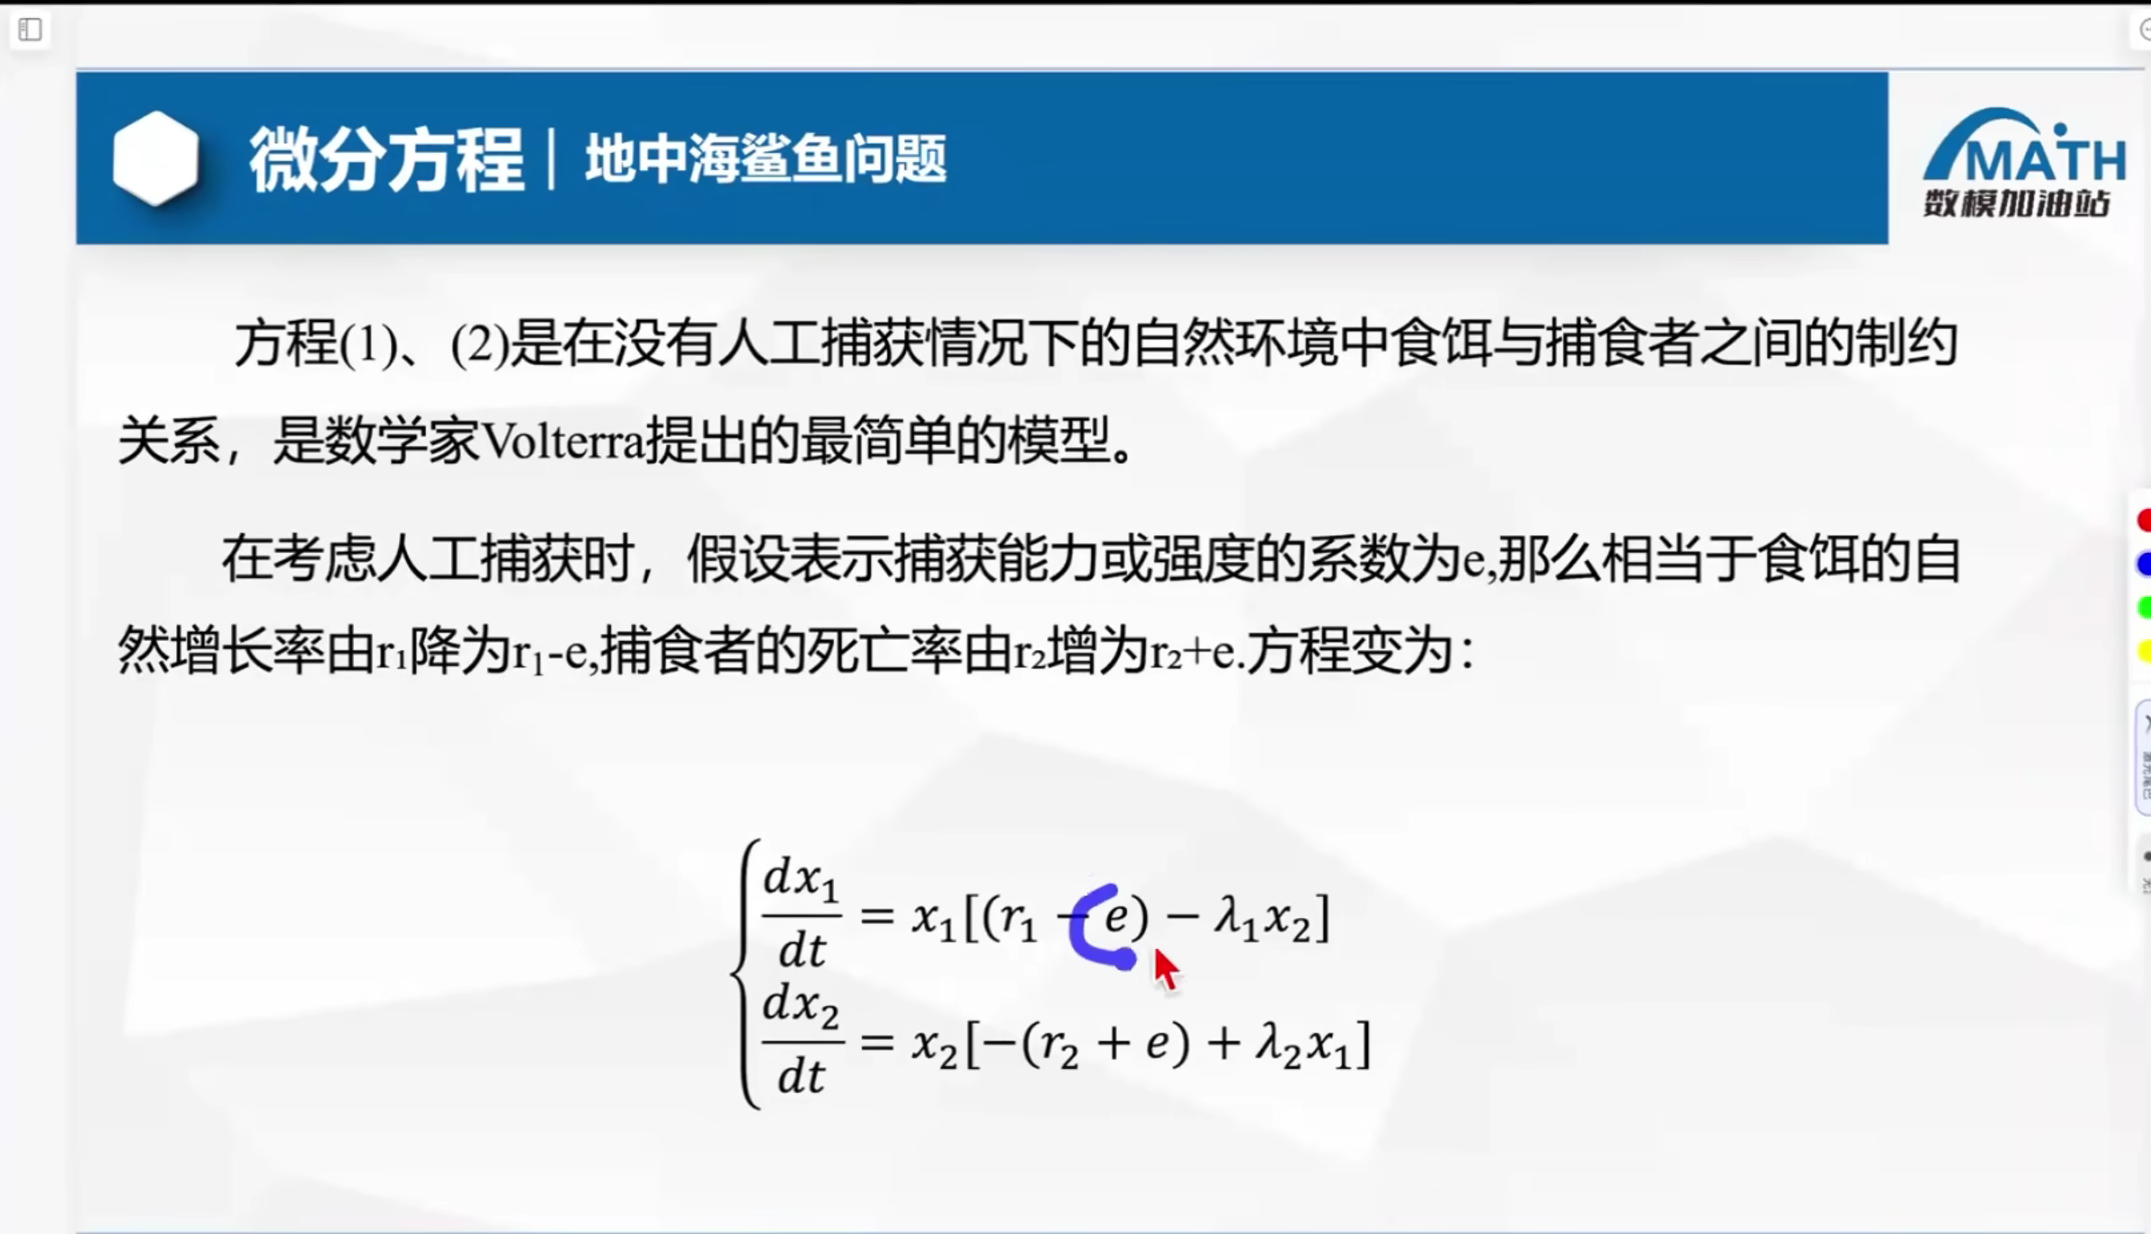

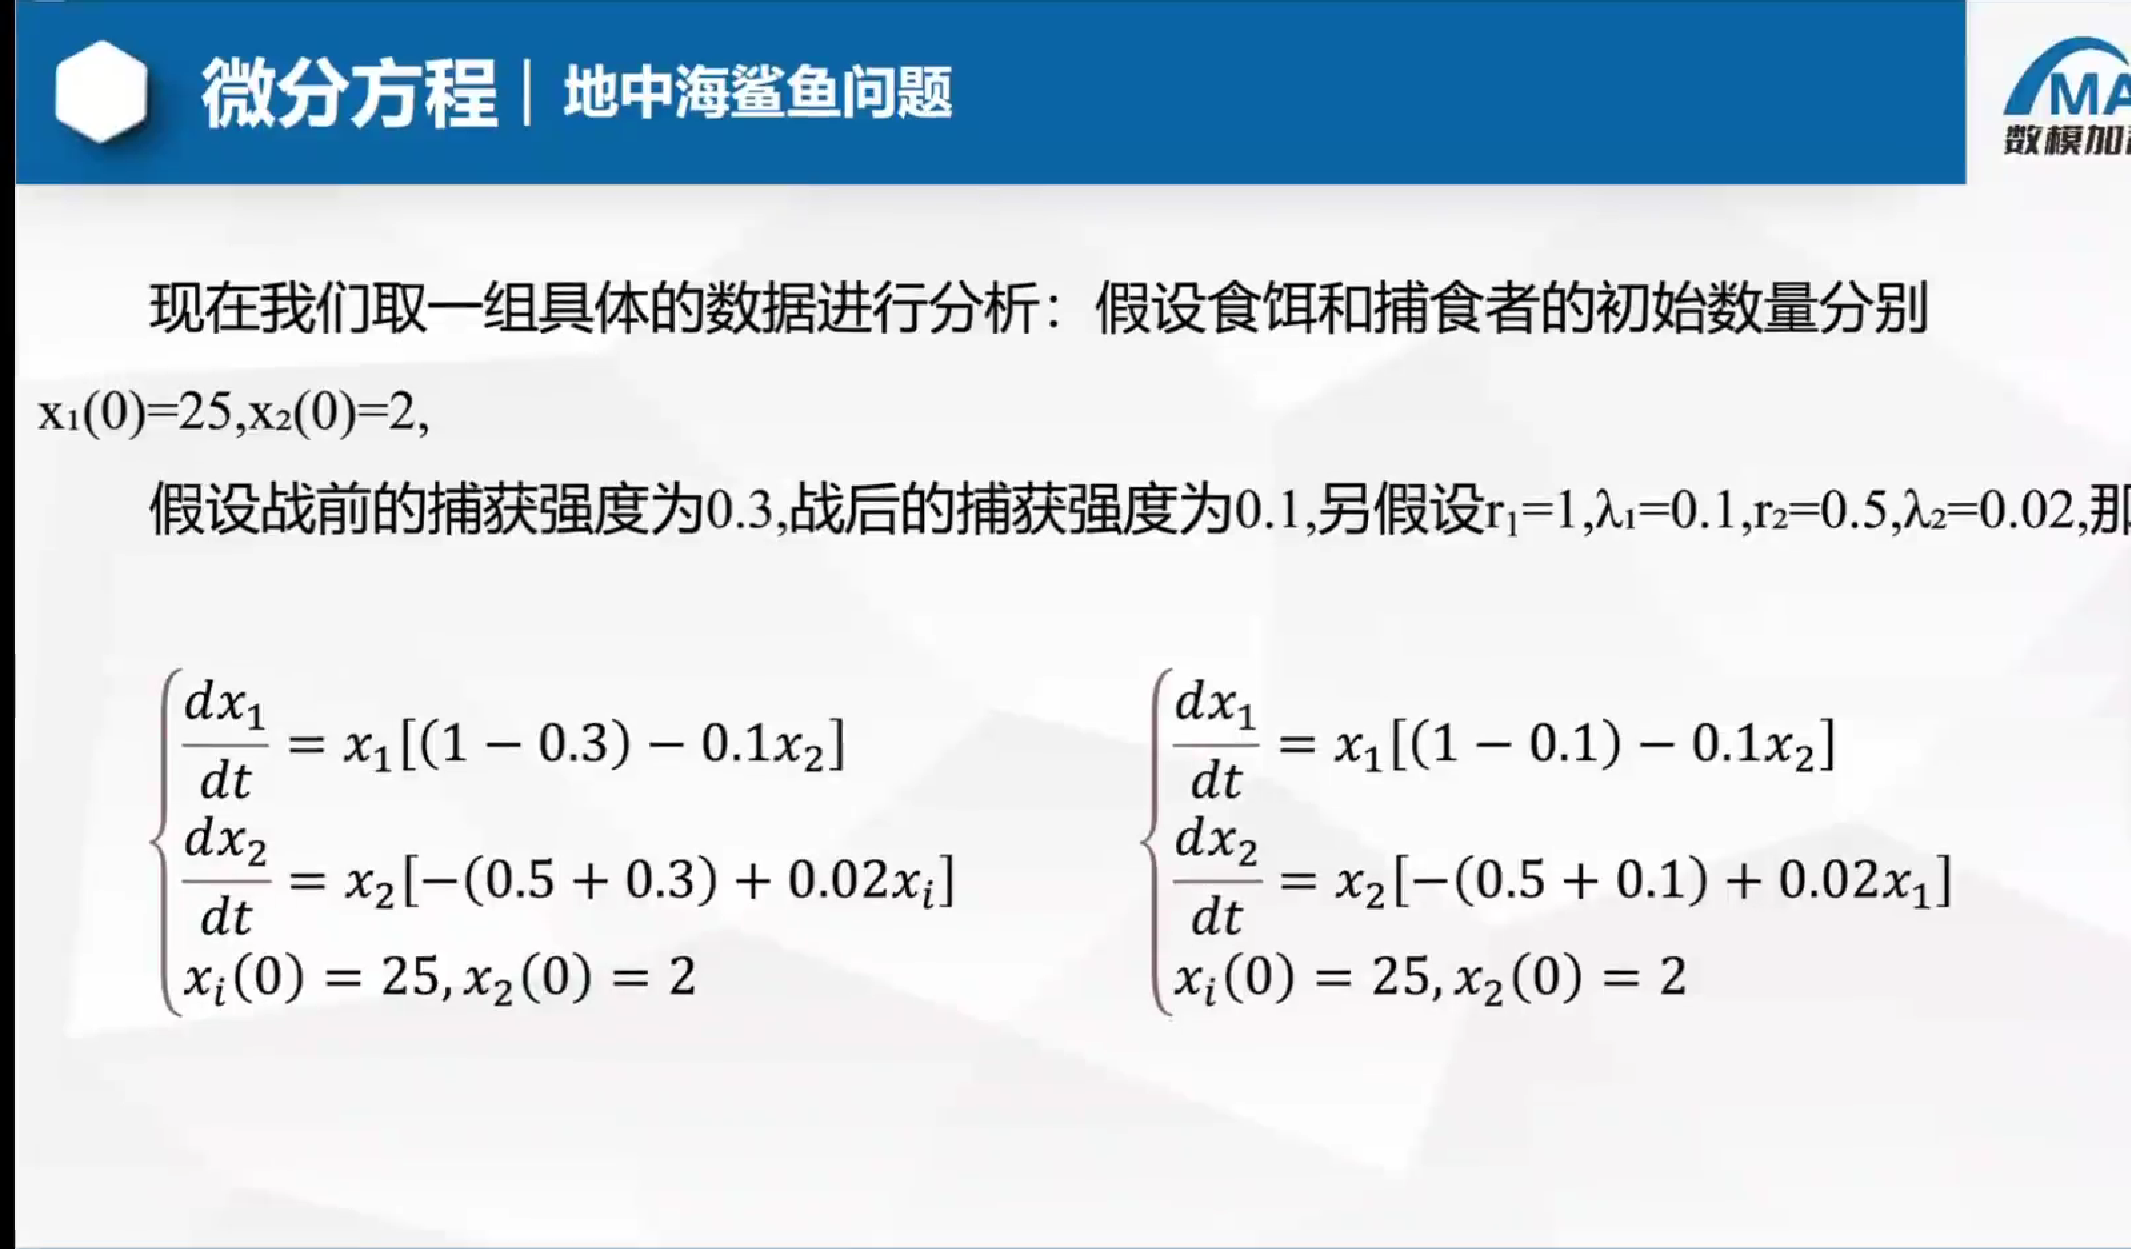

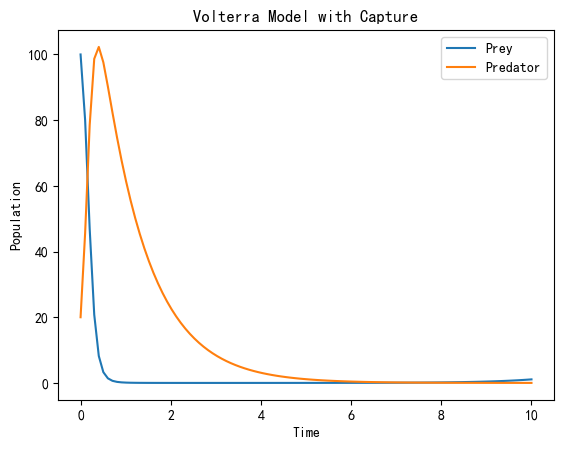

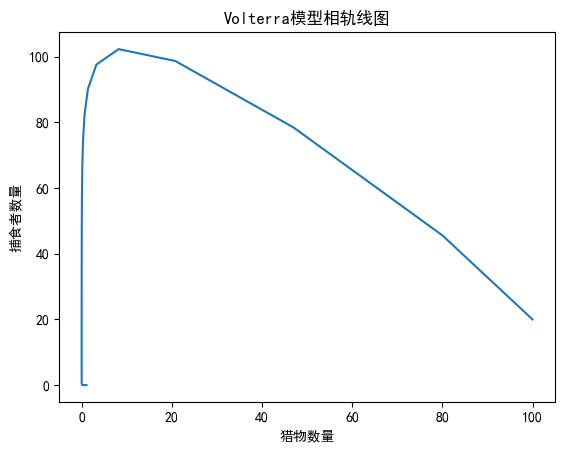

In [9]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

# 定义Volterra模型的微分方程
def volterra_model(X, t, alpha, beta, delta, gamma, c):
    P, V = X
    dPdt = alpha * P - beta * P * V - c * P
    dVdt = delta * P * V - gamma * V
    return [dPdt, dVdt]

# 定义初始条件和参数
P0 = 100      # 初始猎物数量
V0 = 20       # 初始捕食者数量
t = np.linspace(0, 10, 100)  # 时间范围
alpha = 1.0   # 猎物增长率
beta = 0.1    # 捕食者对猎物的影响系数
delta = 0.1   # 猎物对捕食者的影响系数
gamma = 1.0   # 捕食者死亡率
c = 0.05      # 捕获强度

# 求解微分方程
X0 = [P0, V0]  # 初始状态
sol = odeint(volterra_model, X0, t, args=(alpha, beta, delta, gamma, c))
P, V = sol[:, 0], sol[:, 1]

# 绘制猎物和捕食者数量随时间变化的图像
plt.plot(t, P, label='Prey')
plt.plot(t, V, label='Predator')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Volterra Model with Capture')
plt.legend()
plt.show()

# 绘制猎物和捕食者的相轨线图
plt.figure()
plt.plot(P, V)
plt.xlabel('猎物数量')
plt.ylabel('捕食者数量')
plt.title('Volterra模型相轨线图')
plt.show()